# Предобработка базы MIT-BIH для классификации сердечных сокращений

Загружаем сигналы ЭКГ из базы MIT-BIH (формат CSV + аннотации TXT), выполняем фильтрацию, нормализацию и сегментацию отдельных сердечных циклов вокруг R-пиков. Результат сохраняется в сжатый `.npz` файл для дальнейшего обучения моделей.

**Основные шаги:**
1. Загрузка сигнала и аннотаций из файлов CSV/TXT.
2. Полосовая фильтрация (0.5–40 Гц) + режекторный фильтр (50 Гц).
3. Z-нормализация сигнала.
4. Нарезка окон `[R-100, R+150]` отсчётов (250 точек).
5. Отображение примеров сегментов по классам AAMI.
6. Сохранение подготовленных данных.

## Импорт модулей и определение путей

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
from tqdm import tqdm
from collections import Counter

# Путь к папке с данными MIT-BIH (CSV + TXT)
DATA_PATH = './mitbih_database/'

# Частота дискретизации MIT-BIH
FS = 360

# Список всех записей, используемых в базе
RECORDS = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

## Функции загрузки и предобработки

In [16]:
def load_record(record_name, data_path=DATA_PATH, channel=0):
    """
    Загружает один сигнал ЭКГ и аннотации из CSV/TXT файлов MIT-BIH.
    
    Параметры:
    - record_name: имя записи (например '100')
    - data_path: путь к папке с файлами
    - channel: 0 — первое отведение (обычно MLII), 1 — второе (V5)
    
    Возвращает:
    - signal: массив ЭКГ в милливольтах
    - r_peaks: индексы R-пиков (отсчёты)
    - labels: символы аннотаций MIT-BIH
    """
    csv_path = os.path.join(data_path, f'{record_name}.csv')
    df = pd.read_csv(csv_path)
    df.columns = [c.strip().strip("'").strip('"') for c in df.columns]
    
    signal_cols = [c for c in df.columns if c.lower() != 'sample #']
    if channel >= len(signal_cols):
        raise ValueError(f"Канал {channel} не существует в {record_name}. Доступны: {signal_cols}")
    
    signal = df[signal_cols[channel]].to_numpy(dtype=np.float32)
    # Перевод из ADC-единиц в милливольты (gain=200, base=1024)
    signal = (signal - 1024.0) / 200.0
    
    # Загрузка аннотаций
    ann_path = os.path.join(data_path, f'{record_name}annotations.txt')
    r_peaks, labels = [], []
    with open(ann_path, 'r') as f:
        f.readline()  # пропустить заголовок
        for line in f:
            if not line.strip():
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            try:
                sample = int(parts[1])
                symbol = parts[2]
            except (ValueError, IndexError):
                continue
            r_peaks.append(sample)
            labels.append(symbol)
    
    return signal, np.array(r_peaks, dtype=np.int64), np.array(labels)


def bandpass_filter(signal, fs=FS, lowcut=0.5, highcut=40.0, order=4):
    """Полосовой фильтр Баттерворта 0.5–40 Гц."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)


def notch_filter(signal, fs=FS, freq=50.0, quality=30.0):
    """Режекторный фильтр для подавления сетевой наводки 50 Гц."""
    b, a = iirnotch(freq / (fs / 2), quality)
    return filtfilt(b, a, signal)


def denoise(signal, fs=FS):
    """Применяет полосовую фильтрацию и режекцию 50 Гц."""
    signal = bandpass_filter(signal, fs=fs)
    signal = notch_filter(signal, fs=fs, freq=50.0)
    return signal


def zscore_normalize(signal, eps=1e-8):
    """Z-нормализация (среднее=0, std=1)."""
    return (signal - np.mean(signal)) / (np.std(signal) + eps)


# Параметры окна вокруг R-пика (100 отсчётов до, 150 после = 250 точек)
WINDOW_BEFORE = 100
WINDOW_AFTER = 150
WINDOW_SIZE = WINDOW_BEFORE + WINDOW_AFTER   # 250

# Маппинг символов MIT-BIH в 5 классов AAMI
AAMI_MAPPING = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',   # Normal
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',             # Supraventricular ectopic
    'V': 'V', 'E': 'V',                                 # Ventricular ectopic
    'F': 'F',                                           # Fusion
    '/': 'Q', 'f': 'Q', 'Q': 'Q'                        # Unknown
}
CLASS_TO_IDX = {'N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4}
# Количество RR-признаков на удар
N_RR_FEATURES = 6
def compute_rr_features(peaks, fs=FS, local_window=10):
    """
    RR-признаки для последовательности R-пиков ОДНОЙ записи.
    Возвращает массив (n_beats, 6):
      [rr_prev, rr_next, rr_ratio, rr_prev/local, rr_prev/global, local_mean]
    Интервалы rr_prev, rr_next, local_mean — в секундах;
    rr_ratio, rr_prev/local, rr_prev/global — безразмерные отношения.
    """
    n = len(peaks)
    if n == 0:
        return np.zeros((0, N_RR_FEATURES), dtype=np.float32)

    rr_prev = np.zeros(n)
    rr_next = np.zeros(n)
    diffs = np.diff(peaks) / fs          # RR между соседними ударами, сек
    rr_prev[1:] = diffs                   # интервал до предыдущего удара
    rr_next[:-1] = diffs                  # интервал до следующего удара
    # края дублируем, чтобы не было нулей
    rr_prev[0] = rr_next[0] if n > 1 else 1.0
    rr_next[-1] = rr_prev[-1] if n > 1 else 1.0

    valid = rr_prev[rr_prev > 0]
    global_mean = np.median(valid) if valid.size else 1.0

    # локальное среднее RR (скользящее окно ±local_window ударов)
    local_mean = np.empty(n)
    for i in range(n):
        lo, hi = max(0, i - local_window), min(n, i + local_window + 1)
        w = rr_prev[lo:hi]
        w = w[w > 0]
        local_mean[i] = w.mean() if w.size else global_mean

    rr_ratio       = np.divide(rr_prev, rr_next,    out=np.ones(n), where=rr_next > 0)
    rr_prev_local  = np.divide(rr_prev, local_mean, out=np.ones(n), where=local_mean > 0)
    rr_prev_global = rr_prev / global_mean

    return np.column_stack([
        rr_prev, rr_next, rr_ratio, rr_prev_local, rr_prev_global, local_mean
    ]).astype(np.float32)

def segment_beats(signal, r_peaks, labels, before=WINDOW_BEFORE, after=WINDOW_AFTER, fs=FS):
    """
    Нарезает сигнал на окна вокруг каждого R-пика и считает RR-признаки.
    Возвращает:
    - beats: массив формы (N_beats, window_size)
    - beat_labels: массив целочисленных меток (0..4)
    - beat_rr: массив формы (N_beats, 6) — RR-признаки, выровненные по beats
    """
    n = len(signal)

    # Оставляем только реальные удары (отбрасываем '+', '~' и прочие
    # небитовые маркеры), иначе RR-интервалы посчитаются по ложным позициям
    beat_peaks, beat_syms = [], []
    for r_peak, symbol in zip(r_peaks, labels):
        if symbol in AAMI_MAPPING:
            beat_peaks.append(r_peak)
            beat_syms.append(symbol)
    beat_peaks = np.array(beat_peaks, dtype=np.int64)

    # RR считаем по полной последовательности ударов записи,
    # чтобы соседи (prev/next) были корректны
    rr_all = compute_rr_features(beat_peaks, fs=fs)

    # Шаг 3: вырезаем окна; удары, выходящие за границы сигнала, пропускаем,
    # соответствующие им RR-строки тоже не берём (выравнивание сохраняется)
    beats, beat_labels, beat_rr = [], [], []
    for i, (r_peak, symbol) in enumerate(zip(beat_peaks, beat_syms)):
        start = r_peak - before
        end = r_peak + after
        if start < 0 or end > n:
            continue
        beats.append(signal[start:end])
        beat_labels.append(CLASS_TO_IDX[AAMI_MAPPING[symbol]])
        beat_rr.append(rr_all[i])

    return (np.array(beats, dtype=np.float32),
            np.array(beat_labels, dtype=np.int64),
            np.array(beat_rr, dtype=np.float32))


def process_all_records(records=RECORDS, data_path=DATA_PATH):
    """Обрабатывает все записи, возвращает X, y, RR-признаки и id пациентов."""
    X_all, y_all, rr_all, patient_ids = [], [], [], []
    for rec in tqdm(records, desc='Обработка записей'):
        try:
            signal, r_peaks, labels = load_record(rec, data_path)
        except Exception as e:
            print(f'Ошибка при чтении {rec}: {e}')
            continue
        signal = denoise(signal)
        signal = zscore_normalize(signal)
        beats, beat_labels, beat_rr = segment_beats(signal, r_peaks, labels)
        X_all.append(beats)
        y_all.append(beat_labels)
        rr_all.append(beat_rr)
        patient_ids.append(np.full(len(beats), int(rec)))
    X   = np.concatenate(X_all,  axis=0)
    y   = np.concatenate(y_all,  axis=0)
    Xrr = np.concatenate(rr_all, axis=0)
    pids = np.concatenate(patient_ids, axis=0)
    return X, y, Xrr, pids

## Проверка загрузки одной записи (например, 100)

In [17]:
signal, r_peaks, labels = load_record('100')
print(f"Длина сигнала: {len(signal)} отсчётов ({len(signal)/FS:.1f} сек)")
print(f"Количество аннотаций: {len(r_peaks)}")
print(f"Первые 5 меток: {labels[:5]}")
print(f"Первые 5 R-пиков (индексы): {r_peaks[:5]}")

Длина сигнала: 650000 отсчётов (1805.6 сек)
Количество аннотаций: 2274
Первые 5 меток: ['+' 'N' 'N' 'N' 'N']
Первые 5 R-пиков (индексы): [ 18  77 370 662 946]


## Обработка всех записей из списка RECORDS

> **Примечание:** Папка `DATA_PATH` содержит все `.csv` и `annotations.txt` файлы для указанных записей. Если какой-то файл отсутствует, запись будет пропущена с выводом ошибки.

In [6]:
X, y, X_rr, pids = process_all_records(RECORDS)
print(f'Форма X: {X.shape}')   # (количество битов, 250)
print(f'Форма y: {y.shape}')
print(f'Форма pids: {pids.shape}')

Обработка записей: 100%|██████████| 48/48 [00:21<00:00,  2.25it/s]

Форма X: (109449, 250)
Форма y: (109449,)
Форма pids: (109449,)


## Распределение классов AAMI

In [7]:
class_names = ['N (Normal)', 'S (Supraventricular ectopic)', 'V (Ventricular ectopic)', 'F (Fusion)', 'Q (Unknown)']
print("Распределение классов:")
for idx, name in enumerate(class_names):
    count = np.sum(y == idx)
    print(f'  {name}: {count:>6} ({100*count/len(y):.2f}%)')

Распределение классов:
  N (Normal):  90592 (82.77%)
  S (Supraventricular ectopic):   2781 (2.54%)
  V (Ventricular ectopic):   7235 (6.61%)
  F (Fusion):    802 (0.73%)
  Q (Unknown):   8039 (7.34%)


## Визуализация примеров сегментов по классам

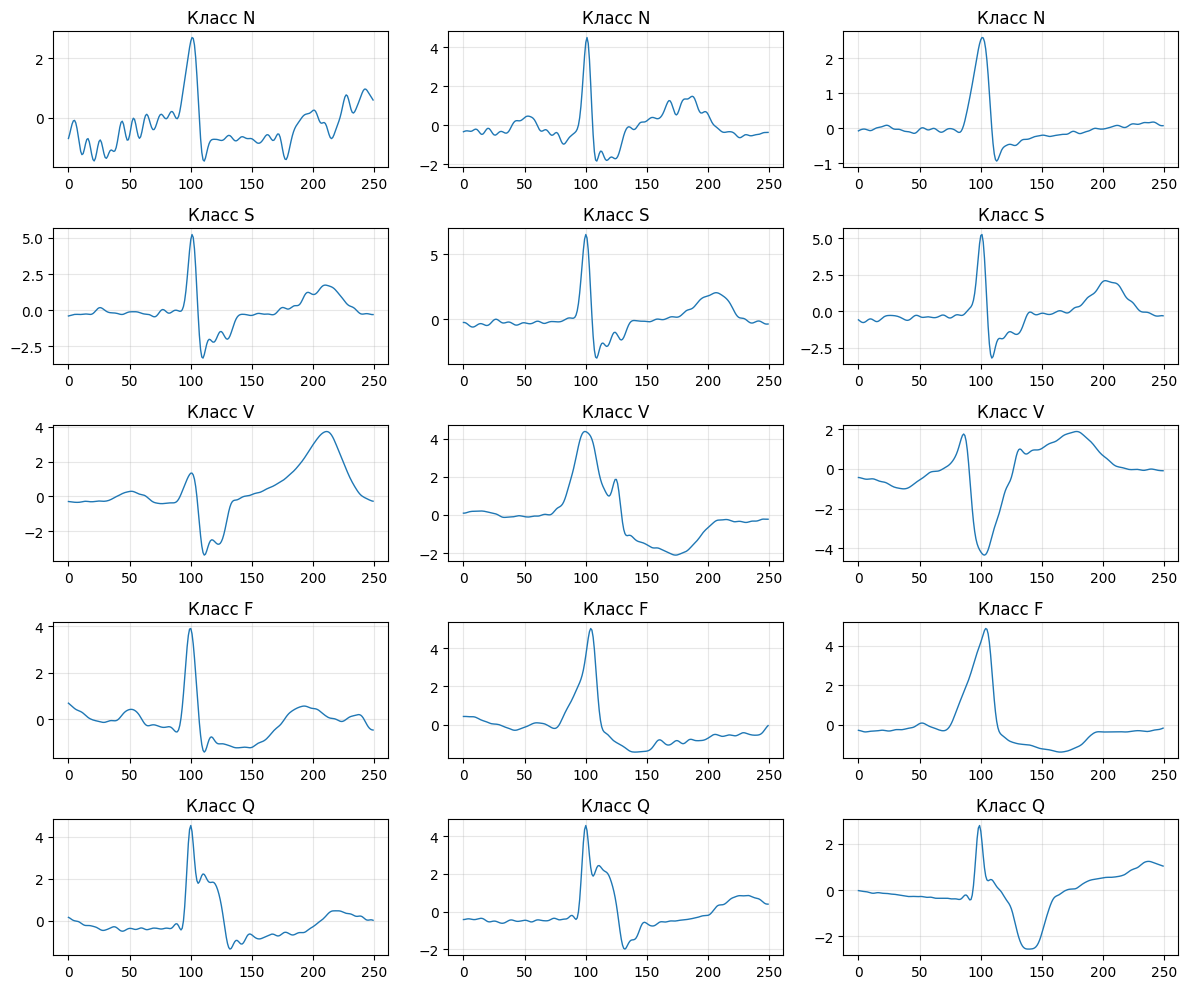

In [8]:
def plot_examples(X, y, n_per_class=3):
    fig, axes = plt.subplots(5, n_per_class, figsize=(12, 10))
    class_short = ['N', 'S', 'V', 'F', 'Q']
    for cls_idx, short in enumerate(class_short):
        idxs = np.where(y == cls_idx)[0]
        if len(idxs) == 0:
            continue
        chosen = np.random.choice(idxs, min(n_per_class, len(idxs)), replace=False)
        for j, beat_idx in enumerate(chosen):
            ax = axes[cls_idx, j]
            ax.plot(X[beat_idx], linewidth=1)
            ax.set_title(f'Класс {short}')
            ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_examples(X, y)

### Визуализации RR-признаков

In [14]:
CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']

RR_FEATURE_NAMES = [
    'RR_prev (сек)',
    'RR_next (сек)',
    'RR_ratio (prev/next)',
    'RR_prev / local_mean',
    'RR_prev / global_mean',
    'local_mean (сек)',
]

# Цвета по классам
CLASS_COLORS = {'N': '#4C72B0', 'S': '#DD8452', 'V': '#55A868',
                'F': '#C44E52', 'Q': '#8172B3'}


def plot_rr_distributions(X_rr, y, class_names=CLASS_NAMES, bins=60):
    """
    Гистограммы каждого RR-признака в разрезе классов.
    Показывает, насколько RR разделяет классы (особенно S vs N).
    """
    n_feat = X_rr.shape[1]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()

    for f in range(n_feat):
        ax = axes[f]
        vals = X_rr[:, f]
        # диапазон по 1–99 перцентилю, чтобы выбросы не сплющивали график
        lo, hi = np.percentile(vals, [1, 99])
        for cls_idx, cls_name in enumerate(class_names):
            mask = (y == cls_idx)
            if mask.sum() == 0:
                continue
            ax.hist(vals[mask], bins=bins, range=(lo, hi),
                    density=True, alpha=0.5,
                    label=f'{cls_name} (n={mask.sum()})',
                    color=CLASS_COLORS.get(cls_name))
        ax.set_title(RR_FEATURE_NAMES[f])
        ax.set_xlabel('значение')
        ax.set_ylabel('плотность')
        ax.legend(fontsize=8)

    fig.suptitle('Распределение RR-признаков по классам', fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_rr_boxplots(X_rr, y, class_names=CLASS_NAMES):
    """Box-plot каждого RR-признака по классам — компактный обзор медиан и разброса."""
    n_feat = X_rr.shape[1]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.ravel()

    for f in range(n_feat):
        ax = axes[f]
        data_by_cls, labels_present = [], []
        for cls_idx, cls_name in enumerate(class_names):
            mask = (y == cls_idx)
            if mask.sum() == 0:
                continue
            data_by_cls.append(X_rr[mask, f])
            labels_present.append(cls_name)
        bp = ax.boxplot(data_by_cls, labels=labels_present, showfliers=False,
                        patch_artist=True)
        for patch, name in zip(bp['boxes'], labels_present):
            patch.set_facecolor(CLASS_COLORS.get(name, '#999999'))
            patch.set_alpha(0.6)
        ax.set_title(RR_FEATURE_NAMES[f])
        ax.set_ylabel('значение')

    fig.suptitle('RR-признаки по классам (box-plot)', fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_rr_scatter(X_rr, y, fx=3, fy=0, class_names=CLASS_NAMES, max_per_class=2000):
    """
    Scatter двух RR-признаков. По умолчанию:
      fx = RR_prev/local_mean, fy = RR_prev — плоскость, где S часто отделяется от N.
    max_per_class — прореживание, чтобы N (десятки тысяч точек) не залил график.
    """
    fig, ax = plt.subplots(figsize=(9, 7))
    rng = np.random.default_rng(42)
    for cls_idx, cls_name in enumerate(class_names):
        mask = np.where(y == cls_idx)[0]
        if mask.size == 0:
            continue
        if mask.size > max_per_class:
            mask = rng.choice(mask, max_per_class, replace=False)
        ax.scatter(X_rr[mask, fx], X_rr[mask, fy],
                   s=8, alpha=0.4, label=cls_name,
                   color=CLASS_COLORS.get(cls_name))
    ax.set_xlabel(RR_FEATURE_NAMES[fx])
    ax.set_ylabel(RR_FEATURE_NAMES[fy])
    ax.set_title('RR-признаки: разделение классов')
    ax.legend()
    # обрезаем оси по перцентилям
    ax.set_xlim(np.percentile(X_rr[:, fx], [1, 99]))
    ax.set_ylim(np.percentile(X_rr[:, fy], [1, 99]))
    fig.tight_layout()
    plt.show()


def rr_summary_table(X_rr, y, class_names=CLASS_NAMES):
    """Печатает медиану RR-признаков по классам — числовая сводка к графикам."""
    print(f'{"Признак":<24}' + ''.join(f'{c:>10}' for c in class_names))
    print('-' * (24 + 10 * len(class_names)))
    for f in range(X_rr.shape[1]):
        row = f'{RR_FEATURE_NAMES[f]:<24}'
        for cls_idx in range(len(class_names)):
            mask = (y == cls_idx)
            med = np.median(X_rr[mask, f]) if mask.sum() else float('nan')
            row += f'{med:>10.3f}'
        print(row)

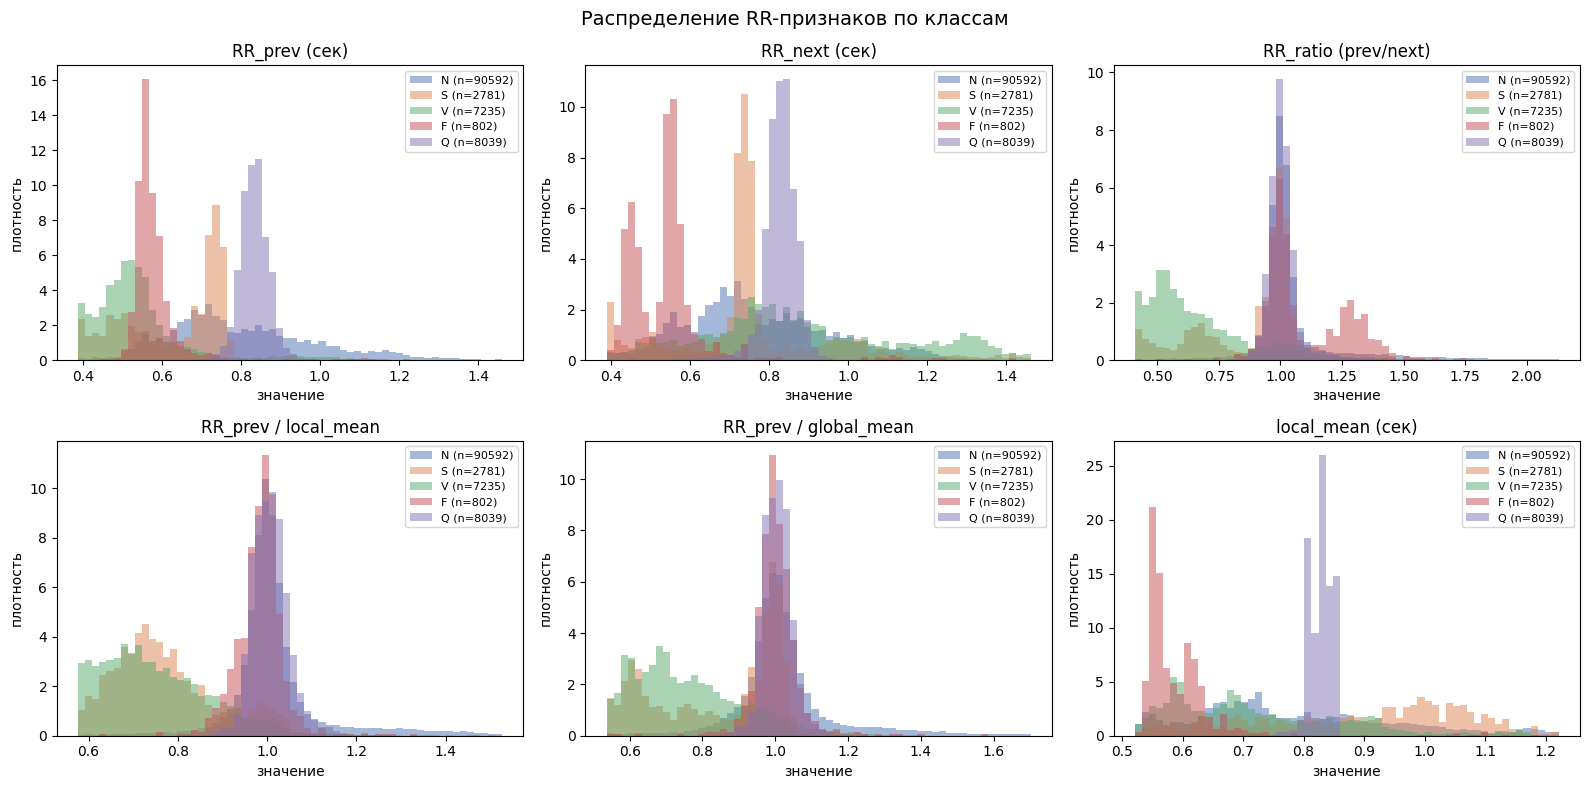

C:\Users\koren\AppData\Local\Temp\ipykernel_18976\1493622509.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cls, labels=labels_present, showfliers=False,
C:\Users\koren\AppData\Local\Temp\ipykernel_18976\1493622509.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cls, labels=labels_present, showfliers=False,
C:\Users\koren\AppData\Local\Temp\ipykernel_18976\1493622509.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_cls, labels=labels_present, showfliers=False,
C:\Users\koren\AppData\Local\Temp\ipykernel_18976\1493622509.py:64: Matpl

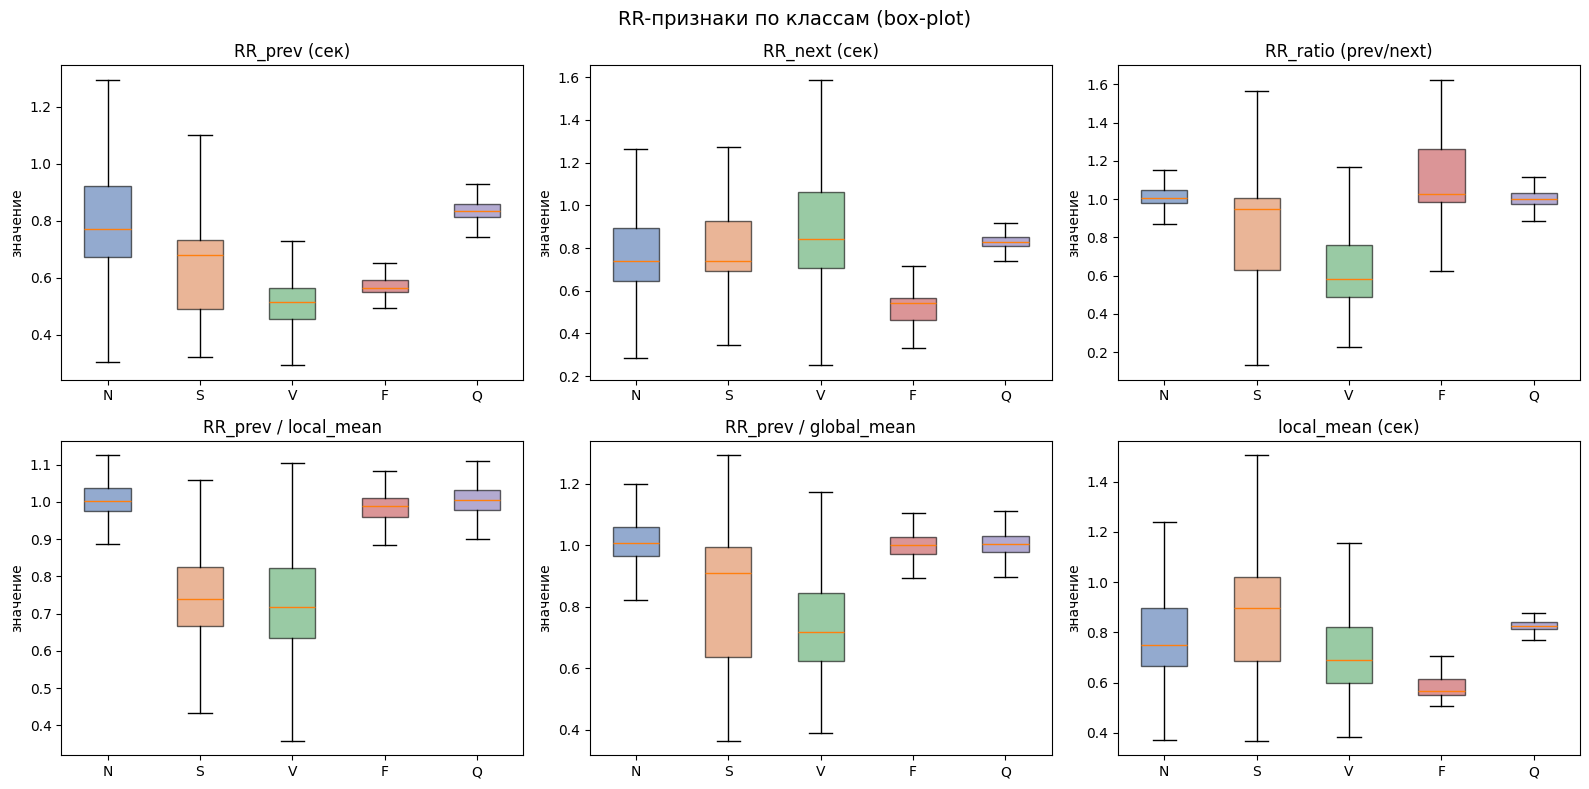

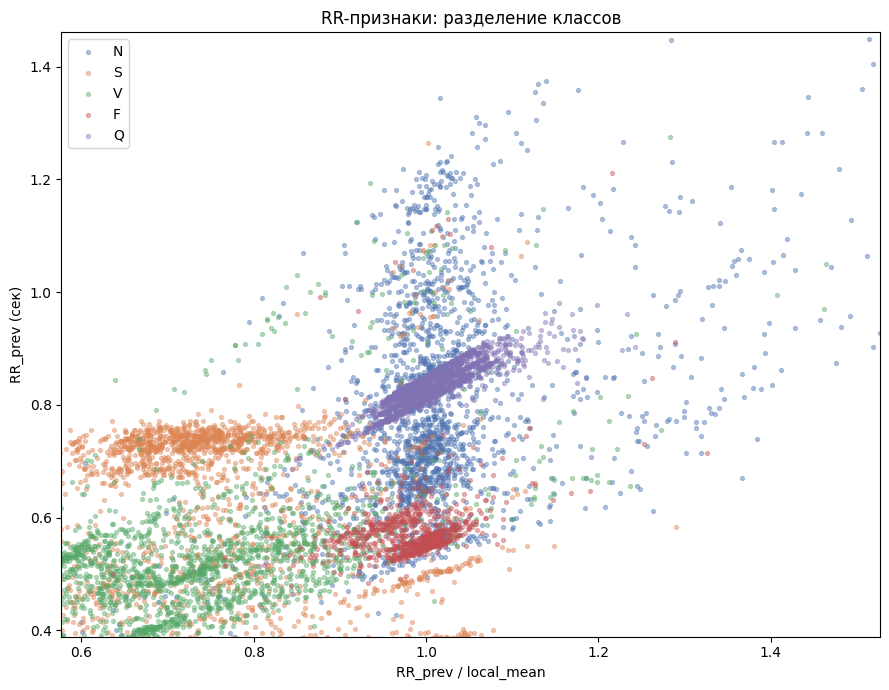

Признак                          N         S         V         F         Q
--------------------------------------------------------------------------
RR_prev (сек)                0.769     0.678     0.514     0.564     0.833
RR_next (сек)                0.742     0.742     0.842     0.542     0.831
RR_ratio (prev/next)         1.008     0.947     0.585     1.029     1.003
RR_prev / local_mean         1.003     0.740     0.717     0.988     1.005
RR_prev / global_mean        1.006     0.910     0.717     1.000     1.003
local_mean (сек)             0.750     0.896     0.689     0.568     0.827


In [18]:
plot_rr_distributions(X_rr, y)
plot_rr_boxplots(X_rr, y)
plot_rr_scatter(X_rr, y)      # RR_prev/local vs RR_prev
rr_summary_table(X_rr, y)

## Таблица подтверждает, что RR-признаки работают.

S отделяется от N


N: 1.003 — нормальный удар приходит вовремя, интервал равен локальному среднему.
S: 0.740 — суправентрикулярный удар приходит на ~26% раньше ожидаемого.
Экстрасистола преждевременна. По форме сигнала (те самые 250 отсчётов) S и N почти неразличимы. Теперь у модели есть признак, где медианы разъезжаются на 0.26 — это сильный, читаемый сигнал.

RR_ratio добавляет второй ракурс: S = 0.947 против N = 1.008. Умеренно короткий prev относительно next — снова признак преждевременности.

V отделяется ещё резче
RR_ratio: V = 0.585 — очень короткий RR_prev и длинный компенсаторный RR_next. Классическая желудочковая экстрасистола с компенсаторной паузой.
RR_next: V = 0.842 (самый длинный из всех) — та самая пауза после ЖЭ.
RR_prev / local_mean: V = 0.717.
V и раньше неплохо ловился по форме (широкий QRS), а теперь получает независимое подтверждение по ритму. Ждите роста и по нему.


F (слияние): почти неотличим от N по ритму. RR_prev/local = 0.988, RR_ratio = 1.029 — практически как у N.

Q: медианы как у N по всем относительным признакам (0.005–1.005). 

### Вывод:

RR-признаки дают прямой разделяющий сигнал по двум из четырёх содержательных классов — S и V, причём S это именно тот класс, который был провален.

## Сохранение подготовленных данных

Данные сохраняются в сжатый файл `mitbih_preprocessed.npz`, содержащий массивы `X`, `y`, `pids`.

In [20]:
np.savez_compressed(
    './models/mitbih_preprocessed.npz',
    X=X.astype(np.float32),
    y=y.astype(np.int64),
    X_rr=X_rr.astype(np.float32),
    pids=pids.astype(np.int32)
)
print("Данные сохранены в 'mitbih_preprocessed.npz'")

Данные сохранены в 'mitbih_preprocessed.npz'



Загрузить файл `mitbih_preprocessed.npz` для обучения моделей классификации сердечных сокращений.

```python
data = np.load('mitbih_preprocessed.npz')
X, y, pids = data['X'], data['y'], data['pids']
```